In [42]:
import numpy as np
import cv2
from PIL import Image
import os

import matplotlib.pyplot as plt

### Download & visualize images

In [8]:
working_dir = 'camera_calibration/undistorted'
files = next(os.walk(working_dir))[2]
files = list(filter(lambda x: x.endswith('.jpg'), files))
files = sorted(files)

In [9]:
images = []
for file in files:
     #read images from data folder
    img = cv2.imread(os.path.join(working_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    images.append(img)

### Define 8 keypoints for every image

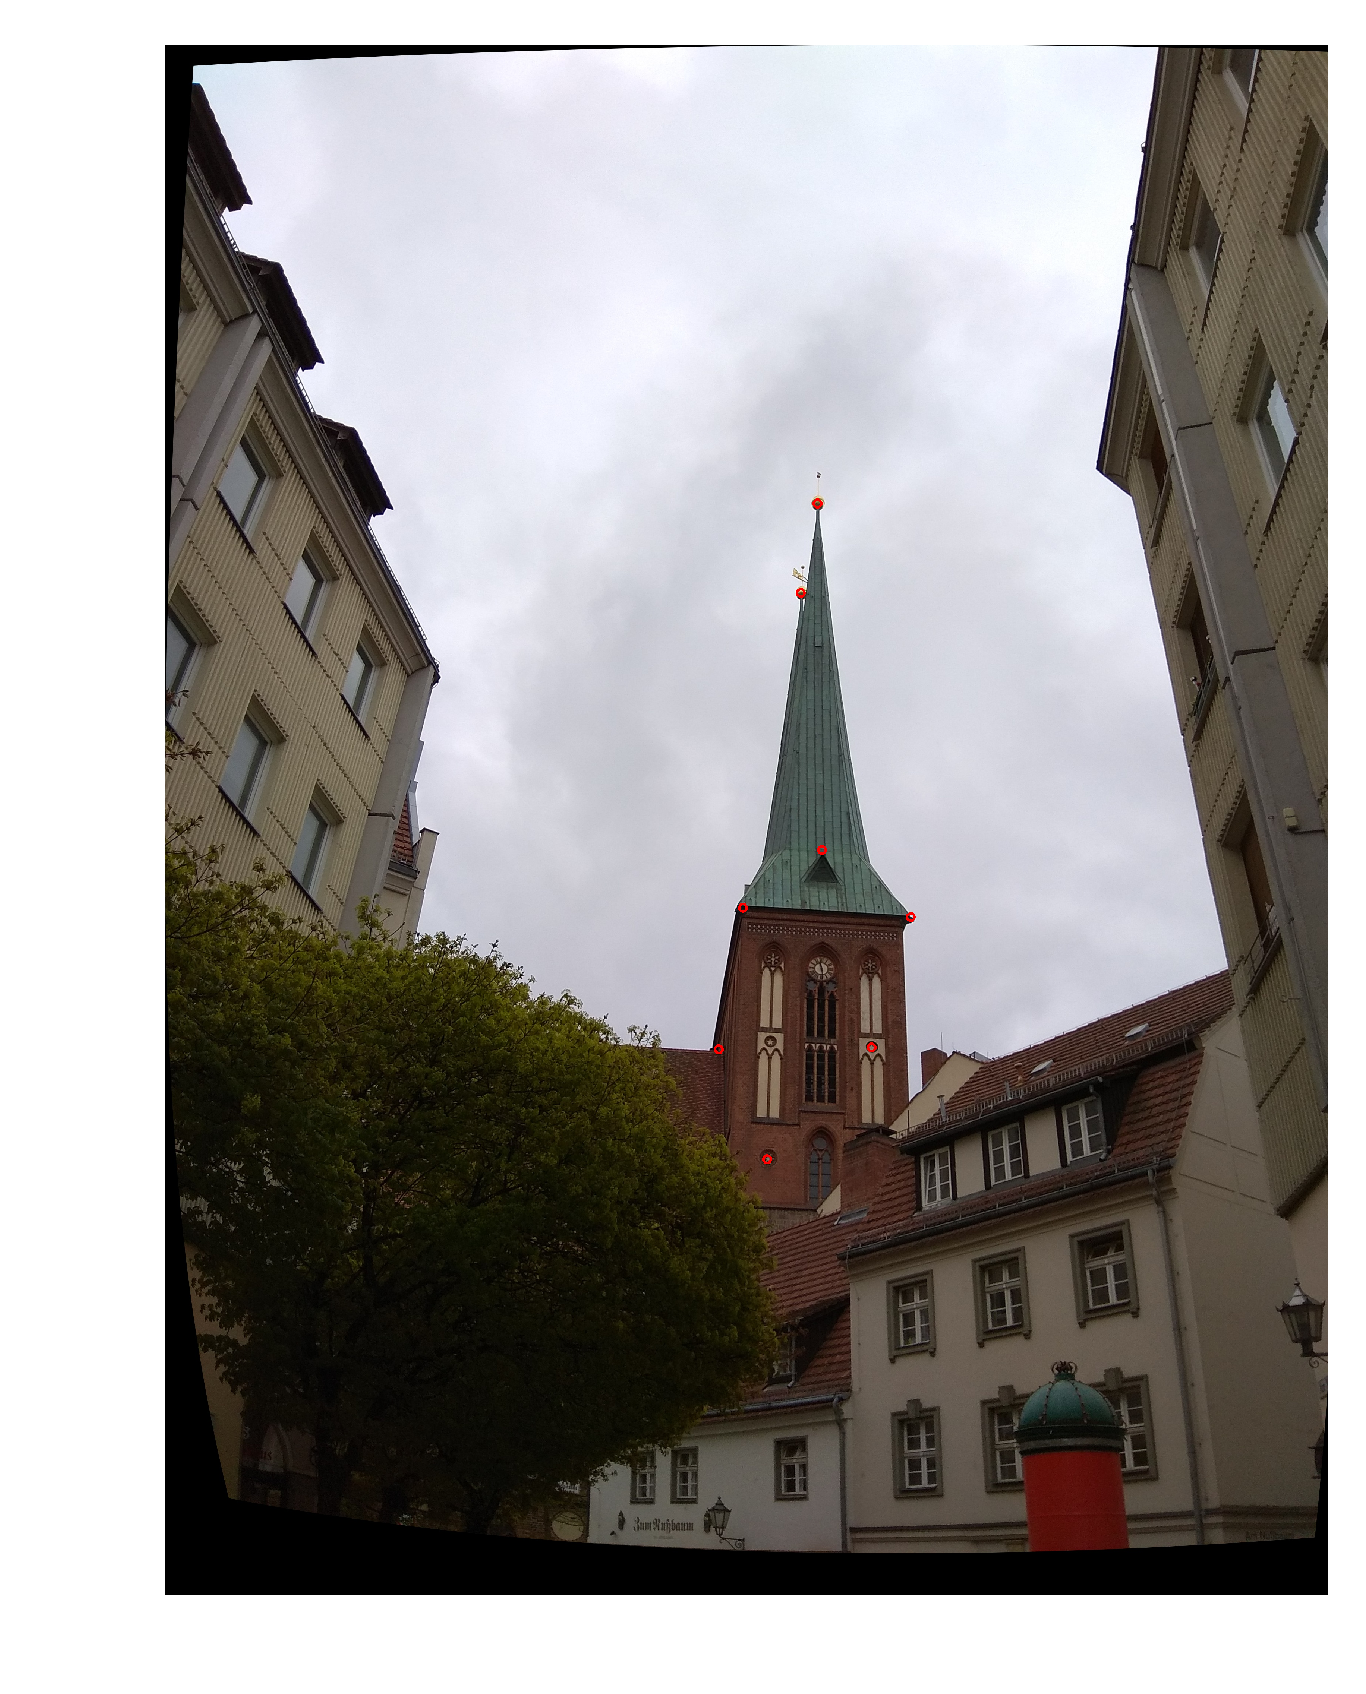

In [11]:
img = np.array(images[0]).copy()

points_one = [(1750, 1230),
              (2000, 2340),
              (1550, 2315),
              (1705, 1470),
              (1762, 2160),
              (1615, 2990),
              (1485, 2695),
              (1895, 2690)]

for point in points_one:
    cv2.circle(img, point, 10, (255, 0, 0), 5)

plt.figure(figsize=(5, 10), dpi=300)
plt.axis('off')
plt.imshow(img)

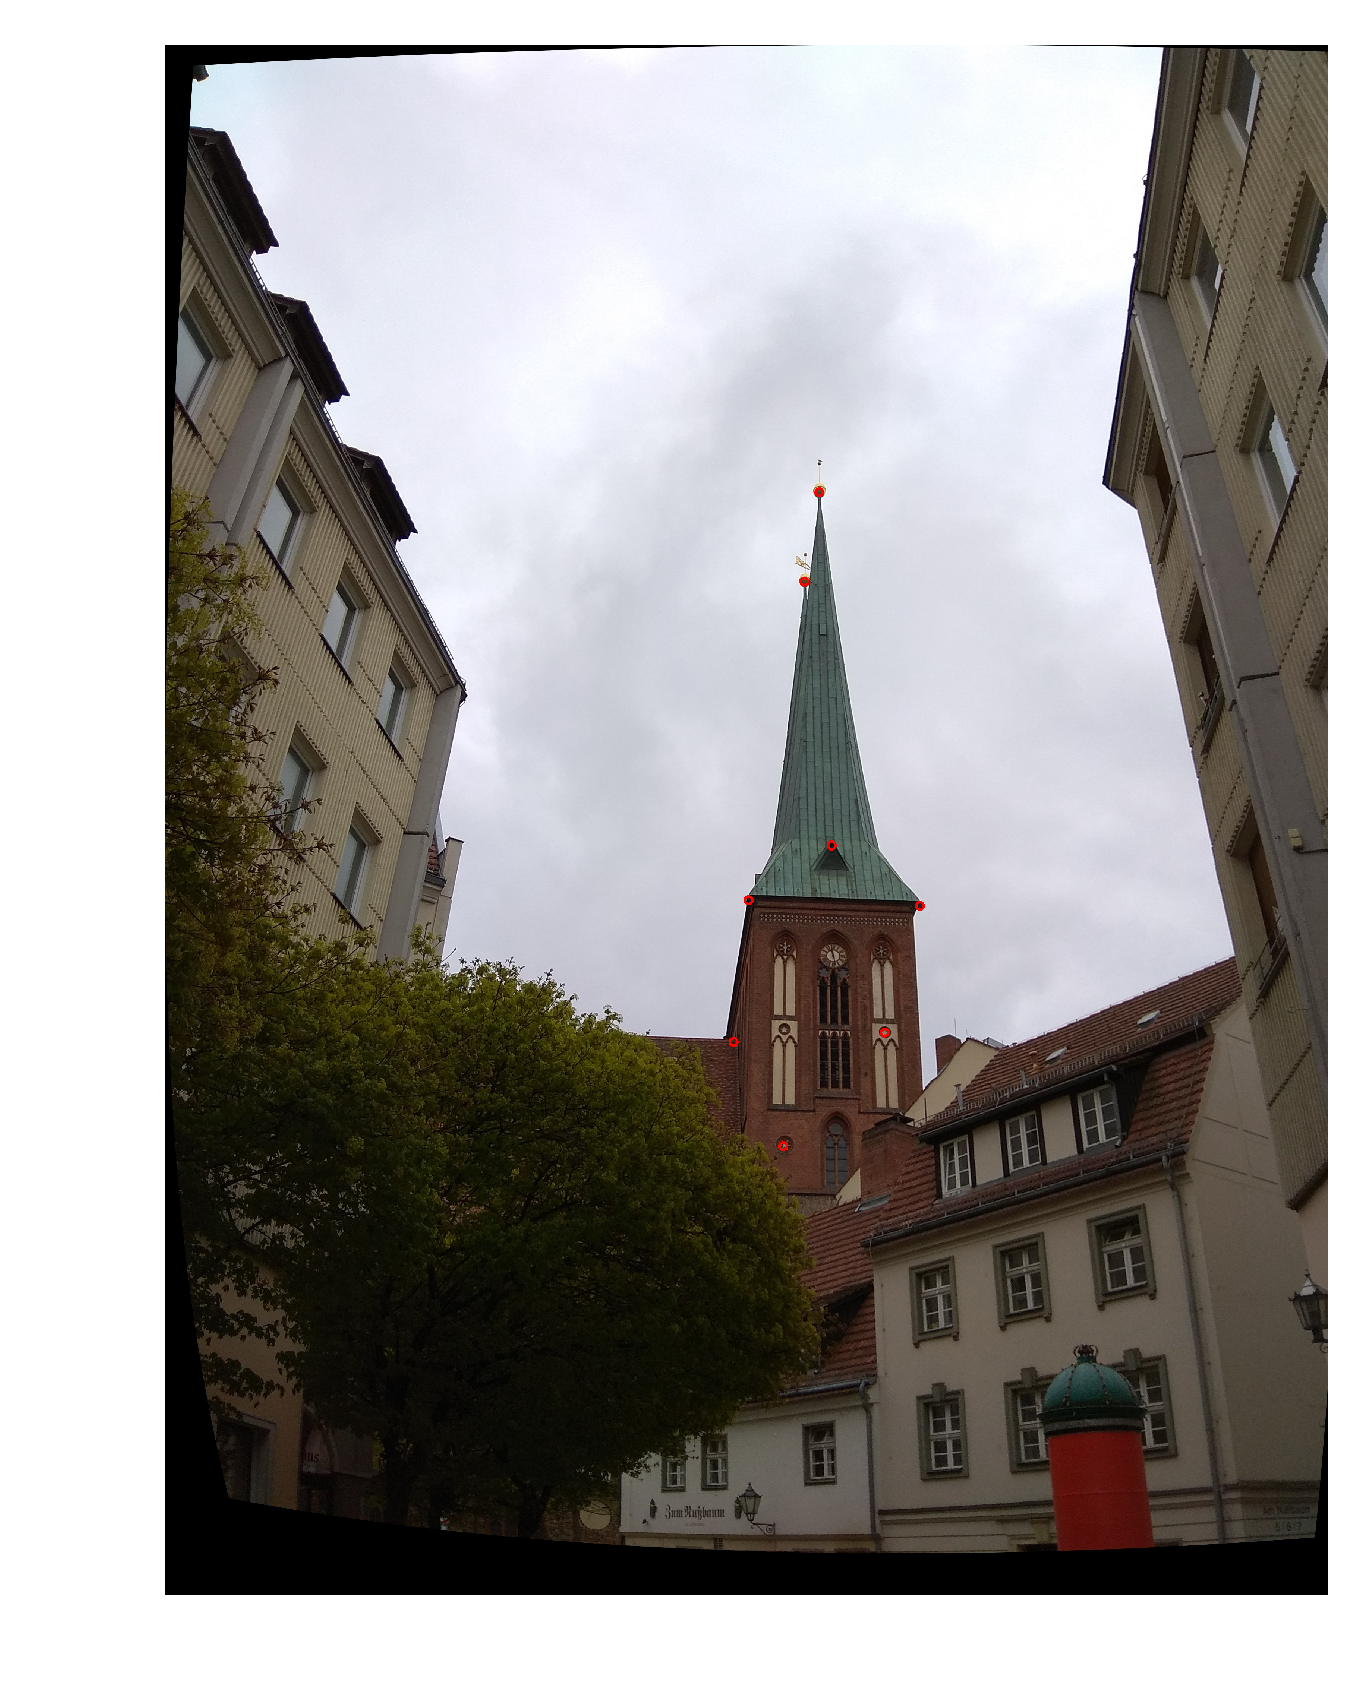

In [12]:
img = np.array(images[1]).copy()

points_two = [(1755, 1200),
              (2025, 2310),
              (1565, 2295),
              (1715, 1440),
              (1788, 2148),
              (1658, 2955),
              (1525, 2675),
              (1930, 2650)]

for point in points_two:
    cv2.circle(img, point, 10, (255, 0, 0), 5)

plt.figure(figsize=(5, 10), dpi=300)
plt.axis('off')
plt.imshow(img)

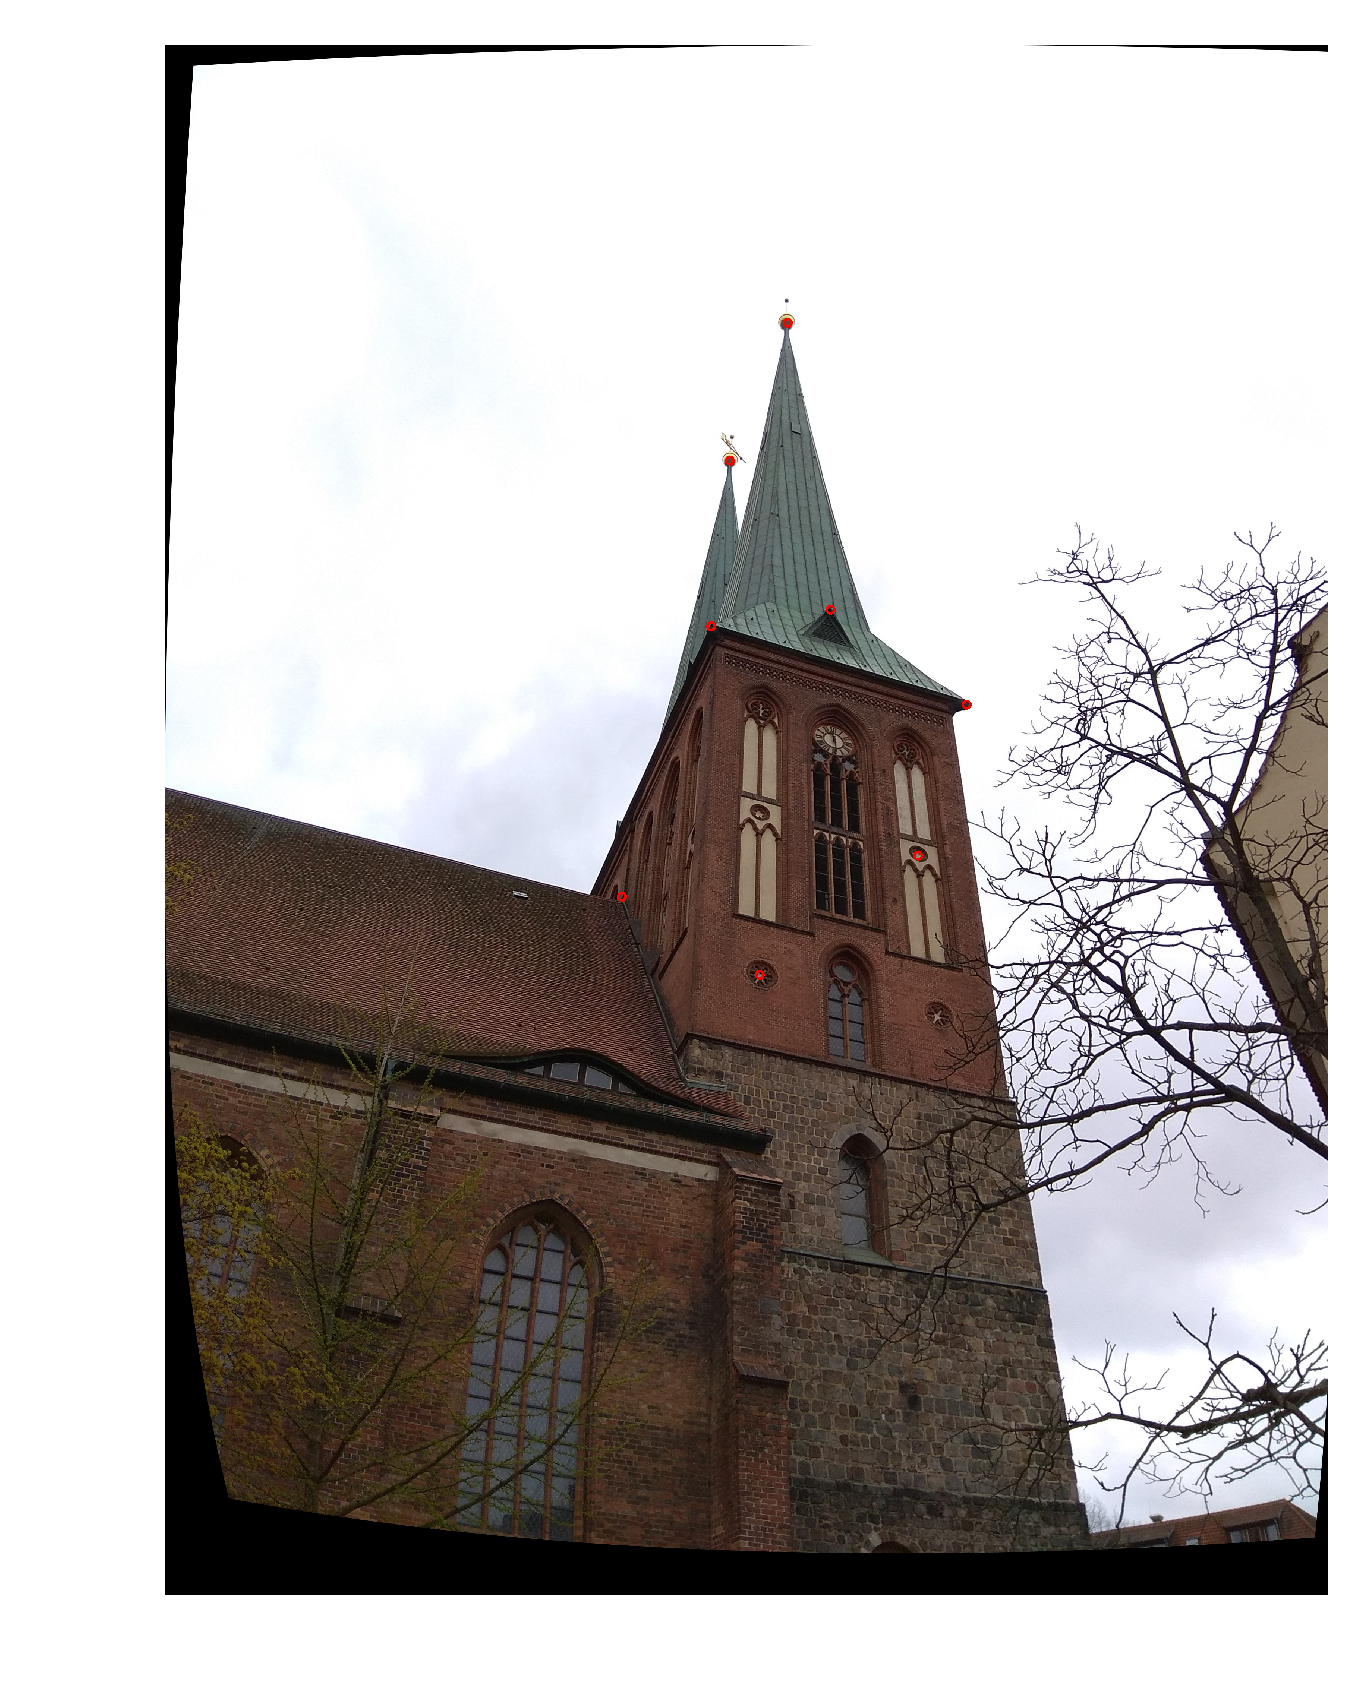

In [14]:
img = np.array(images[2]).copy()

points_three = [(1670, 745),
                (2150, 1770),
                (1465, 1560),
                (1515, 1115),
                (1785, 1515),
                (1595, 2495),
                (1225, 2285),
                (2020, 2175)]

for point in points_three:
    cv2.circle(img, point, 10, (255, 0, 0), 5)

plt.figure(figsize=(5, 10), dpi=300)
plt.axis('off')
plt.imshow(img)

### Compute fundamental matrix

In [27]:
class Epipolar(object):
    
    def __init__(self, l_points, r_points):
        
        assert len(l_points) == len(r_points)
        
        # set keypoints from left and right image
        self.left_points = np.array(l_points, dtype=np.int32)
        self.right_points = np.array(r_points, dtype=np.int32)
        self.size = len(self.left_points)
        
    def compute_fundamental_matrix(self):
        
        # create matrix F
        matrix = []
        
        for l_point, r_point in zip(self.left_points, self.right_points):
            
            vector = np.array([r_point[0] * l_point[0],
                               r_point[0] * l_point[1],
                               r_point[0],
                               r_point[1] * l_point[0],
                               r_point[1] * l_point[1],
                               r_point[1],
                               l_point[0],
                               l_point[1],
                               1.0])
            
            matrix.append(vector)
        
        # find matrix F as the eigenvector with smallest value
        matrix = np.array(matrix)
        u, d, v = np.linalg.svd(matrix)
        self.fundamental = v[-1, :].reshape((3, 3))
        
        # set F with rank equal to 2
        u, d, v = np.linalg.svd(self.fundamental)
        self.fundamental = u @ np.diag(np.array([d[0], d[1], 0])) @ v
        self.fundamental = self.fundamental.astype(np.double)
    
    def compute_epipole(self):
        # compute epipole from fundamental matrix
        u, d, v = np.linalg.svd(self.fundamental)
        self.e = v[-1]
        return self.e / self.e[2]
    
    def compute_camera_matrices(self):
        # left epipole
        self.compute_epipole()  
        Te = cross_product(self.e)
        
        self.P1 = np.c_[np.eye(3), np.zeros(3)]
        self.P2 = np.vstack((np.dot(Te, self.fundamental.transpose()).transpose(), self.e)).transpose()
    
    def linear_triangulation(self):
        # linear triangulation between lines
        p1 = np.c_[self.left_points, np.ones(self.size)].transpose()
        p2 = np.c_[self.right_points, np.ones(self.size)].transpose()
        m1 = self.P1
        m2 = self.P2
        
        num_points = p1.shape[1]
        res = np.ones((4, num_points))

        for i in range(num_points):
            A = np.asarray([
                (p1[0, i] * m1[2, :] - m1[0, :]),
                (p1[1, i] * m1[2, :] - m1[1, :]),
                (p2[0, i] * m2[2, :] - m2[0, :]),
                (p2[1, i] * m2[2, :] - m2[1, :])
            ])

            _, _, V = np.linalg.svd(A)
            X = V[-1, :4]
            res[:, i] = X / X[3]

        return res

In [28]:
def cross_product(x):
    # vectorize the cross product operator
    # via matrix multiplication
    return np.array([[0., -x[2], x[1]],
                     [x[2], 0., -x[0]],
                     [-x[1], x[0], 0.]])

In [37]:
obj = Epipolar(points_one, points_three)
obj.compute_fundamental_matrix()
obj.compute_camera_matrices()
reconstructed = obj.linear_triangulation()

In [41]:
reconstructed = reconstructed.transpose()[:, :3]

### Visualize resulted 3D reconstruction from 2 images

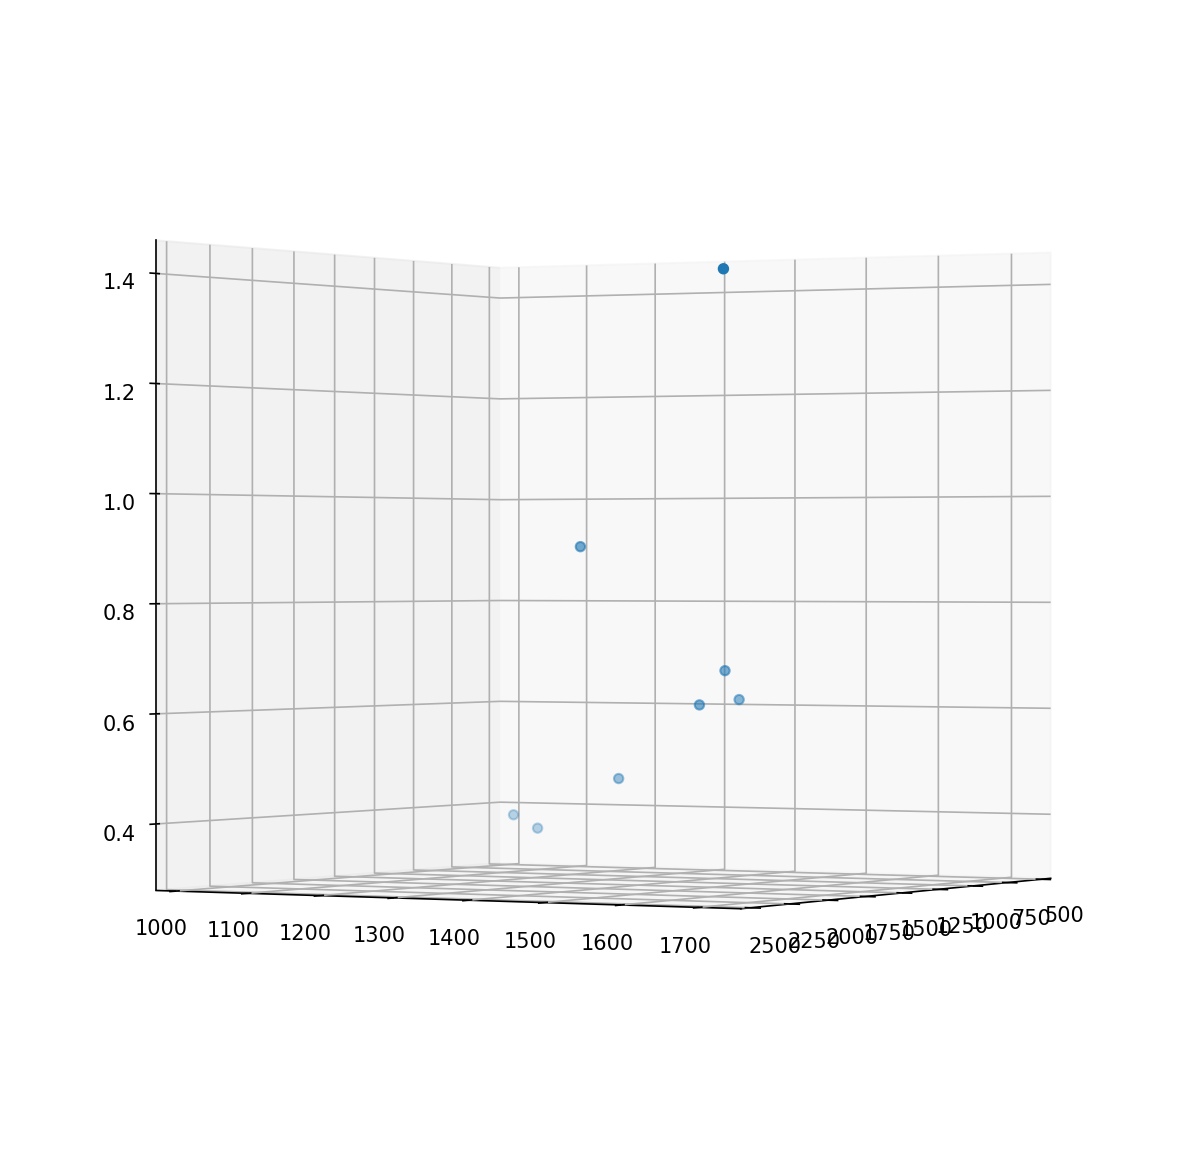

In [67]:
plt.figure(figsize=(10, 10), dpi=150)
ax = plt.axes(projection='3d')
ax.view_init(0, 30)
ax.scatter3D(reconstructed[:, 0],
             reconstructed[:, 1],
             reconstructed[:, 2])

### Currently we have a projective ambiguity type, because we don't have constraint on the form of camera matrix. 